# Credit-risk tutorial

The full workflow: mine candidate constraints from data, review and accept them, price a missing-value flip, build a rating ladder, and generate diverse alternatives.

In [1]:
import numpy as np

rng = np.random.default_rng(42)
n = 6000
names = [
    "income_monthly", "utilization", "n_active_loans", "n_loans_total",
    "max_dpd_30d", "max_dpd_12m", "months_since_last_delinq", "age",
]
income = rng.lognormal(8.3, 0.5, n).round(-1)
utilization = rng.beta(2, 3, n).round(3)
n_total = rng.poisson(4, n).astype(float) + 1
n_active = np.minimum(np.floor(n_total * rng.beta(3, 2, n)), n_total)
dpd_12m = np.floor(rng.exponential(6, n)) * (rng.random(n) < 0.4)
dpd_30d = np.floor(dpd_12m * rng.beta(2, 4, n))
months_delinq = rng.exponential(14, n).round(0)
months_delinq[dpd_12m == 0] = np.nan          # no delinquency -> no record
age = rng.integers(21, 75, n).astype(float)

X = np.column_stack([income, utilization, n_active, n_total,
                     dpd_30d, dpd_12m, months_delinq, age])
risk = (
    -0.9 * np.log(income / 4000)
    + 2.2 * utilization
    + 0.35 * dpd_30d + 0.15 * dpd_12m
    - 0.02 * np.nan_to_num(months_delinq, nan=36.0)
    - 0.015 * age
)
y = (risk + rng.logistic(scale=0.8, size=n) > np.median(risk)).astype(int)
X.shape, y.mean().round(3)

((6000, 8), np.float64(0.534))

In [2]:
import xgboost as xgb

model = xgb.XGBClassifier(n_estimators=120, max_depth=4, learning_rate=0.2,
                          random_state=0)
model.fit(X, y)
model.get_booster().feature_names = list(names)   # domain names for explanations
proba = model.predict_proba(X)[:, 1]
cutoff = 0.30                     # the credit policy's PD cutoff
applicant = X[int(np.argmax(proba))]      # a clearly declined applicant
float(model.predict_proba(applicant.reshape(1, -1))[0, 1])

0.9998112320899963

## 1. Mine candidate constraints

Invariants are mined from the sample and returned **for review** — nothing is auto-applied. Note the DPD hierarchy and loan-count order arriving as ready-to-paste code.

In [3]:
import treecf

mined = treecf.suggest_constraints(X, feature_names=names)
for s in mined[:8]:
    print(s.as_code())

constraint("n_active_loans <= n_loans_total")  # support=1.0000, n=6000
constraint("max_dpd_30d <= max_dpd_12m")  # support=1.0000, n=6000
constraint("max_dpd_12m <= income_monthly")  # support=1.0000, n=6000
constraint("months_since_last_delinq <= income_monthly")  # support=1.0000, n=2044
constraint("age <= income_monthly")  # support=1.0000, n=6000
constraint("utilization <= n_loans_total")  # support=1.0000, n=6000
constraint("n_loans_total <= age")  # support=1.0000, n=6000
constraint("max_dpd_30d <= age")  # support=1.0000, n=6000


In [4]:
accepted = [s.constraint for s in mined
            if s.kind == "order" and s.support == 1.0]
accepted

[Linear(coefficients={'n_active_loans': 1.0, 'n_loans_total': -1.0}, op='<=', rhs=0.0, missing_policy='satisfied'),
 Linear(coefficients={'max_dpd_30d': 1.0, 'max_dpd_12m': -1.0}, op='<=', rhs=0.0, missing_policy='satisfied'),
 Linear(coefficients={'max_dpd_12m': 1.0, 'income_monthly': -1.0}, op='<=', rhs=0.0, missing_policy='satisfied'),
 Linear(coefficients={'months_since_last_delinq': 1.0, 'income_monthly': -1.0}, op='<=', rhs=0.0, missing_policy='satisfied'),
 Linear(coefficients={'age': 1.0, 'income_monthly': -1.0}, op='<=', rhs=0.0, missing_policy='satisfied'),
 Linear(coefficients={'utilization': 1.0, 'n_loans_total': -1.0}, op='<=', rhs=0.0, missing_policy='satisfied'),
 Linear(coefficients={'n_loans_total': 1.0, 'age': -1.0}, op='<=', rhs=0.0, missing_policy='satisfied'),
 Linear(coefficients={'max_dpd_30d': 1.0, 'age': -1.0}, op='<=', rhs=0.0, missing_policy='satisfied')]

## 2. Explain with a priced missing-value flip

`months_since_last_delinq` is NaN when there is no delinquency record — and *reaching* that state is a legitimate recommendation with an explicit price (`delta_miss`).

In [5]:
from treecf import AllowMissing, Explainer, Freeze, Target

exp = Explainer(
    model,
    background=X,
    constraints=accepted + [
        Freeze("age"),
        AllowMissing("months_since_last_delinq", delta_miss=2.0),
    ],
    value_policy={"max_dpd_30d": "integer", "max_dpd_12m": "integer",
                  "n_active_loans": "integer", "n_loans_total": "integer"},
)
res = exp.explain(applicant, target=Target.probability(range=(0.0, cutoff)),
                  seed=0)
res.changes

{'income_monthly': (5550.0, 5519.99951171875),
 'utilization': (0.727, 0.27648804594936227),
 'max_dpd_30d': (12.0, 0.0),
 'max_dpd_12m': (19.0, 7.0),
 'months_since_last_delinq': (9.0, nan)}

## 3. The rating ladder

One search per band: the increasing cost of each better grade.

In [6]:
ladder = exp.explain(applicant, seed=0, target=Target.bands({
    "approve": (0.00, 0.30),
    "prime":   (0.00, 0.15),
    "super":   (0.00, 0.05),
}))
{k: (round(v.distance, 3) if hasattr(v, 'distance') else v.reason)
 for k, v in ladder.items()}

{'approve': 9.854, 'prime': 13.207, 'super': 15.006}

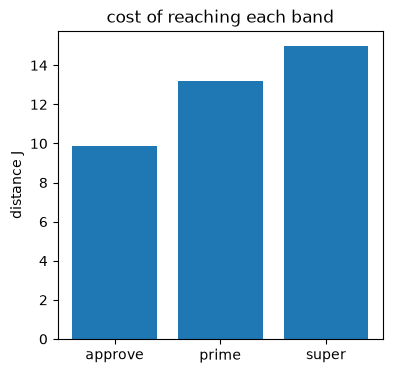

In [7]:
from treecf.viz import plot_ladder

plot_ladder(ladder);

## 4. Alternative plans, and which levers are essential

Block each of the primary plan's biggest levers in turn and re-solve. Levers with a workaround yield an alternative plan (at a higher cost); levers with none are *essential* — approval is unreachable without them. Both answers are useful to an applicant.

In [8]:
from treecf import Infeasible

base = accepted + [Freeze("age"),
                   AllowMissing("months_since_last_delinq", delta_miss=2.0)]
policy = {"max_dpd_30d": "integer", "max_dpd_12m": "integer",
          "n_active_loans": "integer", "n_loans_total": "integer"}
idx = {f: i for i, f in enumerate(names)}
levers = sorted(res.changes,
                key=lambda f: abs(res.changes[f][1] - res.changes[f][0])
                / exp.sigma[idx[f]], reverse=True)[:3]
alternatives, essential = [res], []
for lever in levers:
    alt = Explainer(model, background=X, value_policy=policy,
                    constraints=base + [Freeze(lever)])
    cand = alt.explain(applicant, seed=0, time_budget_s=30,
                       target=Target.probability(range=(0.0, cutoff)))
    if isinstance(cand, Infeasible):
        essential.append(lever)      # no plan exists without this lever
    else:
        alternatives.append(cand)
print("essential levers:", essential)
[(round(a.distance, 2), sorted(a.changes)) for a in alternatives]

essential levers: ['max_dpd_12m', 'max_dpd_30d']


[(9.85,
  ['income_monthly',
   'max_dpd_12m',
   'max_dpd_30d',
   'months_since_last_delinq',
   'utilization']),
 (15.72,
  ['income_monthly',
   'max_dpd_12m',
   'max_dpd_30d',
   'months_since_last_delinq'])]

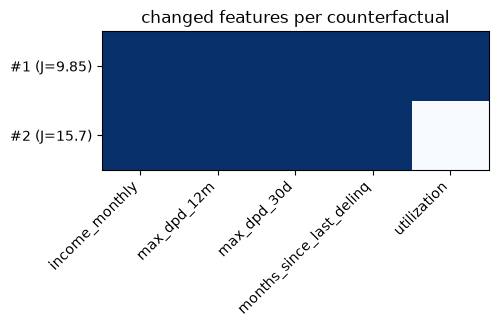

In [9]:
from treecf.viz import plot_counterfactuals

plot_counterfactuals(alternatives);

## 5. Mass-producing counterfactuals for a day's declines

Score a day's applications, take the declines, and produce (up to) two recourse plans per applicant in one call — then store the batch and look plans up later without recomputing.

In [10]:
import time

declined = np.flatnonzero(proba > cutoff)[:200]     # today's declines
app_ids = [f"APP-{i:05d}" for i in declined]

start = time.perf_counter()
batch = exp.explain_batch(
    X[declined],
    target=Target.probability(range=(0.0, cutoff)),
    n_per_example=2,           # counterfactuals per applicant
    diversity="seeds",
    ids=app_ids,
    seed=0,
)
wall = time.perf_counter() - start
feasible = sum(r.feasible for r in batch)
print(f"{len(batch)} plans for {len(declined)} applicants "
      f"in {wall:.1f}s ({1000 * wall / len(declined):.0f} ms/applicant)")
print(f"feasible plans: {feasible}")

271 plans for 200 applicants in 17.4s (87 ms/applicant)
feasible plans: 271


In [11]:
import pathlib, tempfile

store_path = pathlib.Path(tempfile.mkdtemp()) / "counterfactuals_today.json"
batch.save(store_path)                        # store once...

from treecf import BatchResult
stored = BatchResult.load(store_path)
stored.for_id(app_ids[0])                     # ...look up any time

[BatchRecord(id='APP-00000', k=0, feasible=True, x_cf=array([4.69e+03, 3.13e-01, 4.00e+00, 8.00e+00, 0.00e+00, 0.00e+00,
        5.60e+01, 2.90e+01]), changes={'months_since_last_delinq': (nan, 56.0)}, distance=0.2857142857142857, n_changed=1, score_raw=-1.4165606913058202, score_prob=0.19520132496869663, seed=0, blocked_lever=None)]

In [12]:
stored.to_frame().head(6)      # or analyze the whole day as a DataFrame

,id,k,feasible,distance,n_changed,score_raw,score_prob,seed,blocked_lever,changed_features,cf_income_monthly,cf_utilization,cf_n_active_loans,cf_n_loans_total,cf_max_dpd_30d,cf_max_dpd_12m,cf_months_since_last_delinq,cf_age
0,APP-00000,0,True,0.285714,1,-1.416561,0.195201,0,None,[months_since_last_delinq],4690.000000,0.313,4.0,8.0,0.0,0.0,56.0,29.0
1,APP-00001,0,True,0.285714,1,-0.956829,0.277514,1009,None,[months_since_last_delinq],2390.000000,0.222,8.0,9.0,0.0,0.0,54.0,36.0
2,APP-00001,1,True,1.253846,2,-0.919418,0.285077,1011,None,"[income_monthly, n_loans_total]",2720.000000,0.222,8.0,8.0,0.0,0.0,NaN,36.0
3,APP-00002,0,True,0.234899,1,-0.949777,0.278930,2018,None,[utilization],5860.000000,0.037,8.0,10.0,0.0,0.0,NaN,39.0
4,APP-00002,1,True,1.089185,2,-1.284813,0.216732,2021,None,"[income_monthly, n_active_loans]",5744.059685,0.072,7.0,10.0,0.0,0.0,NaN,39.0
5,APP-00003,0,True,1.000000,1,-1.588606,0.169580,3027,None,[n_active_loans],6440.000000,0.142,7.0,12.0,0.0,0.0,NaN,54.0
